<a href="https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Building and Visualizing Emissions Data with Google Data Commons

**Part 2 of 3: Constructing Time Series Datasets and Comparing States**

---

Welcome to the second notebook in the **Google Data Commons for Knowledge Discovery** tutorial series!

In this notebook, we’ll move beyond individual API calls and build a **multi-dimensional dataset** of greenhouse gas emissions across all U.S. states. We'll retrieve **time series data**, combine it with **location metadata**, and visualize patterns using both **static** and **interactive** visualizations.

### 🧭 Previously in Part 1:

We introduced the structure of the [**Knowledge Graph**](https://datacommons.org/browser/), explored how to identify entities using DCIDs, and queried relationship triples using get_triples(). We also visualized entity-level connections using NetworkX, laying the groundwork for deeper exploration.

---

## 🔍 What You'll Learn in This Notebook

- How to build a state-level emissions dataset using `get_stat_series()`
- How to retrieve population and geographic metadata
- How to compute per capita emissions
- How to visualize environmental patterns over time
  - Line plots with Seaborn
  - Interactive dashboards with Plotly
- How Data Commons Retrieved Data Enables Data Enrichement and Advanced Data Analysis by combining data of different sources

---

📚 **Tutorial Series Overview**:

1. ✅ **[Basics of Data Commons and Knowledge Graphs](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb)**  
* Understand the structure of the Data Commons Knowledge Graph

* Use key API functions like `get_triples()` and `get_property_values()`

* Visualize relationships between entities with NetworkX

2. 📈 **[Building and Visualizing Emissions Datasets](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)** (this notebook)  
* Build a time series dataset using `get_stat_series()`

* Combine emissions with population and location metadata

* Visualize environmental trends with `Seaborn` and `Plotly`
3. 🌐 **[Interconnectivity and Event Exploration in GDC](#)**

* Traverse entity relationships across time and geography

* Explore disaster and climate event data

* Build graph-based visualizations of interconnected nodes

> **This notebook assumes you've seen the core API functions, but will reintroduce key methods where needed.**


# Setup Cell — Installation + Imports

Here are the setups you will need to run this notebook

In [54]:
# ⚙️ Setup: Install packages if needed (for Google Colab only)
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install datacommons datacommons_pandas pygraphviz

# 📦 Imports
import datacommons as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# Set inline visuals
%config InlineBackend.figure_format = 'retina'


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


# Short API Recap & Core Concepts Markdown

## 🧠 Quick Recap: What is Data Commons?

This is the recap from the [first notebook](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb) - refer to it for a more detailed breakdown of Data Commons structure and API usage.

Google **Data Commons** integrates open data from sources like the U.S. Census, EPA, and World Bank into a unified **Knowledge Graph**.

In this graph:
- **Entities** (like states, cities, or events) are identified using **DCIDs**
- **Relationships** and **Statistical Variables** connect those entities through time and space

If you're new to these concepts, we recommend reviewing [Notebook 1](#) for:
- Knowledge Graph structure
- Understanding DCIDs and `get_triples()`
- Graph visualization basics

---

## 🛠️ Key API Methods Used in This Notebook

| **Method**                      | **What it does**                                 |
|--------------------------------|--------------------------------------------------|
| `get_places_in()`              | Get all U.S. states (`place_type = "State"`)     |
| `get_stat_series()`            | Retrieve time-series data for a variable         |
| `get_property_values()`        | Fetch metadata (e.g., name, location, nearby)    |

These tools allow us to construct **time-indexed datasets** and enrich them with geographic context.


# Section 1: Retrieving the data with Data Commons

## 🗺️ Step 1: Get All U.S. States and Define Variables

We’ll begin by retrieving all U.S. states from the Data Commons graph using `get_places_in()`.

Then, we’ll define the **statistical variables** that we want to pull for each state, including:
- Greenhouse gas emissions (biogenic & non-biogenic CO₂, methane, nitrous oxide)
- Total population (for per capita normalization)


## ✅ Code Cell: Retrieve States and Define Variables



In [55]:
# Get all US states using place_type = "State"
states_dict = dc.get_places_in(['country/USA'], place_type='State')
states_list = states_dict['country/USA']

# Define the statistical variables we want for each state
variables_list = [
    'Count_Person',
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic'
]

print(f"✅ Retrieved {len(states_list)} states.")


✅ Retrieved 52 states.


### 🔍 What Did We Just Do?

We used the function `get_places_in()` to retrieve the DCIDs for all **U.S. states** from the Data Commons knowledge graph.

Then, we defined a list of **statistical variables** we’ll collect for each state:
- Total population
- CO₂ emissions (biogenic and non-biogenic)
- Methane and nitrous oxide emissions

> ✅ The output confirms that we successfully retrieved **52 state-level entities** (including D.C. and territories, depending on API availability).


## ⏳ Step 2: Retrieve Emissions and Population Time Series

We’ll now loop over each state and each variable to retrieve **annual time series data** using `get_stat_series()`.

Each call returns a dictionary where:
- Keys = years (`'2010'`, `'2021'`, etc.)
- Values = observed metric (e.g., metric tons of CO₂)

We’ll flatten the results into a list of dictionaries to build a tidy Pandas DataFrame.


## ✅ Code Cell: Fetch Time Series Data

In [56]:
# Initialize a list to collect all data points
data = []

# Loop over each state and variable to retrieve time series data
for state in states_list:
    for var in variables_list:
        try:
            stat_series = dc.get_stat_series(state, var)
            for year, value in stat_series.items():
                data.append({
                    'State': state,
                    'Year': year,
                    'Variable': var,
                    'Value': value
                })
        except Exception as e:
            print(f"⚠️ Error fetching {var} for {state}: {e}")


In [57]:
data[:5]

[{'State': 'geoId/01',
  'Year': '1929',
  'Variable': 'Count_Person',
  'Value': 2644000},
 {'State': 'geoId/01',
  'Year': '1916',
  'Variable': 'Count_Person',
  'Value': 2359000},
 {'State': 'geoId/01',
  'Year': '1951',
  'Variable': 'Count_Person',
  'Value': 3059000},
 {'State': 'geoId/01',
  'Year': '2015',
  'Variable': 'Count_Person',
  'Value': 4854803},
 {'State': 'geoId/01',
  'Year': '1947',
  'Variable': 'Count_Person',
  'Value': 2942000}]

### 🗂️ What This Gave Us

We now have a **Python list of dictionaries**, where each dictionary is a data point representing:

- A state (by its DCID, like `'geoId/06'`)
- A year (as a string, like `'2015'`)
- A variable (e.g., `'Count_Person'`)
- A numeric value (e.g., population or emissions)

Here’s an example of what the structure looks like:

```python
[{
    'State': 'geoId/01',
    'Year': '2013',
    'Variable': 'Count_Person',
    'Value': 4831586
}, {
    'State': 'geoId/01',
    'Year': '2010',
    'Variable': 'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Value': 97000000.0
}]


This is still **raw structured data**.

> ✅ In the next step, we’ll convert this into a proper Pandas DataFrame and pivot it into wide format for analysis.

## 🧼 Step 3: Create a Tidy Dataset (Wide Format)

Now that we’ve collected a structured list of time series data, let’s convert it into a **Pandas DataFrame**.

Then we’ll **pivot** it so that:
- Each row represents a unique `(State, Year)`
- Each column corresponds to a different variable (e.g., population, emissions)

This makes it easier to compute metrics like **per capita emissions** and to visualize trends over time.


## ✅ Code Cell: Pivot to Wide Format

In [58]:
# Convert to DataFrame
df_long = pd.DataFrame(data)

# Convert Year to int for easier sorting
df_long['Year'] = df_long['Year'].astype(int)

# Pivot: one row per (State, Year), one column per Variable
df_wide = df_long.pivot_table(
    index=['State', 'Year'],
    columns='Variable',
    values='Value'
).reset_index()

# Optional: sort values for clarity
df_wide = df_wide.sort_values(by=['State', 'Year']).reset_index(drop=True)

df_wide.head()


Variable,State,Year,Annual_Emissions_CarbonDioxide_Biogenic,Annual_Emissions_CarbonDioxide_NonBiogenic,Annual_Emissions_Methane_NonBiogenic,Annual_Emissions_NitrousOxide_NonBiogenic,Count_Person
0,geoId/01,1900,NaN,NaN,NaN,NaN,1830000.0
1,geoId/01,1901,NaN,NaN,NaN,NaN,1907000.0
2,geoId/01,1902,NaN,NaN,NaN,NaN,1935000.0
3,geoId/01,1903,NaN,NaN,NaN,NaN,1957000.0
4,geoId/01,1904,NaN,NaN,NaN,NaN,1978000.0


### 📊 What This Table Shows

You now have a wide-format dataset with one row per **State-Year** combination, and each column representing a **measured variable**.

For example:

| State     | Year | Count_Person | Annual_Emissions_CO₂_NonBiogenic | ... |
|-----------|------|---------------|-------------------------------|------|
| geoId/01  | 2010 | 4,800,000     | 97,000,000                   | ...  |
| geoId/01  | 2011 | 4,820,000     | 96,000,000                   | ...  |

> ✅ In the next step, we’ll compute **per capita emissions** by dividing the emissions values by population.


## 📐 Step 4: Compute Per Capita Emissions

To make meaningful comparisons across states, we’ll normalize emissions data by population size. This gives us **per capita** metrics:

- CO₂ per person (biogenic and non-biogenic)
- Methane per person
- Nitrous oxide per person

We'll add new columns to the DataFrame with `_per_capita` suffixes.


## ✅ Code Cell: Calculate Per Capita Columns

In [59]:
# Create new per capita columns
df_wide['CO2_Bio_per_capita'] = (
    df_wide['Annual_Emissions_CarbonDioxide_Biogenic'] / df_wide['Count_Person']
)

df_wide['CO2_NonBio_per_capita'] = (
    df_wide['Annual_Emissions_CarbonDioxide_NonBiogenic'] / df_wide['Count_Person']
)

df_wide['Methane_per_capita'] = (
    df_wide['Annual_Emissions_Methane_NonBiogenic'] / df_wide['Count_Person']
)

df_wide['N2O_per_capita'] = (
    df_wide['Annual_Emissions_NitrousOxide_NonBiogenic'] / df_wide['Count_Person']
)

# Preview the result
df_wide[['State', 'Year', 'CO2_NonBio_per_capita', 'Methane_per_capita']].head()


Variable,State,Year,CO2_NonBio_per_capita,Methane_per_capita
0,geoId/01,1900,NaN,NaN
1,geoId/01,1901,NaN,NaN
2,geoId/01,1902,NaN,NaN
3,geoId/01,1903,NaN,NaN
4,geoId/01,1904,NaN,NaN


### 📈 What These Columns Represent

Each of these new columns shows **emissions per person**, allowing us to:

- Compare states fairly despite different population sizes
- Track how emissions intensity has changed over time

> ✅ Up next: we’ll enrich this dataset with geographic metadata like state names and coordinates to enable mapping and region-based filtering.


## 🗺️ Step 5: Enrich with Metadata (Name, Location)

We’ve built a solid emissions dataset by state and year — but our current `State` column still uses **DCIDs** (like `'geoId/06'`).

Let’s add additional metadata for each state to make the dataset more readable and flexible for:
- Visualization and labeling
- metadata enrichement


## ✅ Code Cell: Fetch Metadata from Data Commons

In [60]:
# --- Step 5.1: Collect names, lat, lon ---
unique_states = df_wide['State'].unique()
state_names = {}
state_coords = {}

for dcid in unique_states:
    try:
        name = dc.get_property_values([dcid], 'name').get(dcid, [''])[0]
        lat = dc.get_property_values([dcid], 'latitude').get(dcid, [''])[0]
        lon = dc.get_property_values([dcid], 'longitude').get(dcid, [''])[0]

        state_names[dcid] = name
        state_coords[dcid] = (lat, lon)
    except Exception as e:
        print(f"⚠️ Name/coords failed for {dcid}: {e}")






In [61]:
# Show a sample of the metadata collected

print("🔤 State Names (first 5):")
for k in list(state_names.keys())[:5]:
    print(f"{k} → {state_names[k]}")

print("\n📍 State Coordinates (first 5):")
for k in list(state_coords.keys())[:5]:
    lat, lon = state_coords[k]
    print(f"{state_names[k]} → lat: {lat}, lon: {lon}")



🔤 State Names (first 5):
geoId/01 → Alabama
geoId/02 → Alaska
geoId/04 → Arizona
geoId/05 → Arkansas
geoId/06 → California

📍 State Coordinates (first 5):
Alabama → lat: 32.7, lon: -86.7
Alaska → lat: 63.346191, lon: -150
Arizona → lat: 34.2099643, lon: -111.602401
Arkansas → lat: 34.8, lon: -92.2
California → lat: 37, lon: -119.5406515


### ✅ What to Check

You should see:
- ✅ Full state names matched to DCIDs
- ✅ Approximate lat/lon values


This confirms that the **metadata enrichment** step worked before we merge everything into the main emissions dataset.


### What Did We Just Fetch?

### 🧭 Interpreting the Metadata

For each state DCID, we’ve now collected:

| Field            | Description                                     |
|------------------|-------------------------------------------------|
| `name`           | Full state name (e.g., "California")            |
| `latitude`, `longitude` | Approximate geographic center of the state   |


> ✅ In the next step, we’ll merge this metadata into our main dataset so we can use it for labels, filters, and maps.


## 🧩 Step 6: Merge Metadata into the Emissions Dataset

We’ll now map the metadata we retrieved into new columns:

- `Name` → readable state name
- `Lat`, `Lon` → geographic coordinates


This allows us to:
- Use friendly labels in plots

- Later build interactive dashboards


## ✅ Code Cell: Merge Metadata into df_wide

In [62]:
# 🧩 Step 6: Map Metadata into Main Dataset

# Add readable state names
df_wide['Name'] = df_wide['State'].map(state_names)

# Split coordinates into two separate mappings
latitudes = {k: v[0] for k, v in state_coords.items()}
longitudes = {k: v[1] for k, v in state_coords.items()}

# Add latitude and longitude as separate columns
df_wide['Lat'] = df_wide['State'].map(latitudes)
df_wide['Lon'] = df_wide['State'].map(longitudes)



# Preview merged columns
df_wide[['State', 'Name', 'Year', 'CO2_NonBio_per_capita', 'Lat', 'Lon']].head()


Variable,State,Name,Year,CO2_NonBio_per_capita,Lat,Lon
0,geoId/01,Alabama,1900,NaN,32.7,-86.7
1,geoId/01,Alabama,1901,NaN,32.7,-86.7
2,geoId/01,Alabama,1902,NaN,32.7,-86.7
3,geoId/01,Alabama,1903,NaN,32.7,-86.7
4,geoId/01,Alabama,1904,NaN,32.7,-86.7


### ✅ What You Should See Now

Each row should include:

- A readable state name (e.g., "Alabama")
- Geographic coordinates (`Lat`, `Lon`)



## 🧹 Step 7: Final Clean-Up and Dataset Overview

We’ve now created a dataset that combines:

- Time series data on emissions and population
- Derived per capita metrics
- Geographic metadata (names, coordinates)

We removed the `Nearby_Places` field since it’s not supported at the state level in Data Commons.

Let’s preview the final dataset before visualizing it.


## ✅ Code Cell:  Preview the final enriched dataset

In [63]:
# Preview the final dataset
df_wide.head()


Variable,State,Year,Annual_Emissions_CarbonDioxide_Biogenic,Annual_Emissions_CarbonDioxide_NonBiogenic,Annual_Emissions_Methane_NonBiogenic,Annual_Emissions_NitrousOxide_NonBiogenic,Count_Person,CO2_Bio_per_capita,CO2_NonBio_per_capita,Methane_per_capita,N2O_per_capita,Name,Lat,Lon
0,geoId/01,1900,NaN,NaN,NaN,NaN,1830000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
1,geoId/01,1901,NaN,NaN,NaN,NaN,1907000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
2,geoId/01,1902,NaN,NaN,NaN,NaN,1935000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
3,geoId/01,1903,NaN,NaN,NaN,NaN,1957000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
4,geoId/01,1904,NaN,NaN,NaN,NaN,1978000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7


In [64]:
df_wide.columns

Index(['State', 'Year', 'Annual_Emissions_CarbonDioxide_Biogenic',
       'Annual_Emissions_CarbonDioxide_NonBiogenic',
       'Annual_Emissions_Methane_NonBiogenic',
       'Annual_Emissions_NitrousOxide_NonBiogenic', 'Count_Person',
       'CO2_Bio_per_capita', 'CO2_NonBio_per_capita', 'Methane_per_capita',
       'N2O_per_capita', 'Name', 'Lat', 'Lon'],
      dtype='object', name='Variable')

## 🧾 Final Dataset Columns (So Far)

Here’s what each column in our `df_wide` dataset represents:

| Column                          | Description                                                                 |
|---------------------------------|-----------------------------------------------------------------------------|
| `State`                         | DCID (Data Commons ID) for the state, e.g., `geoId/06`                      |
| `Name`                          | Human-readable state name (e.g., `"California"`)                            |
| `Year`                          | Year of the observation                                                     |
| `Count_Person`                  | Total population in that state and year                                     |
| `Annual_Emissions_CarbonDioxide_Biogenic` | Annual CO₂ emissions from **biogenic** sources (e.g., forests, ag)       |
| `Annual_Emissions_CarbonDioxide_NonBiogenic` | Annual CO₂ emissions from **non-biogenic** sources (e.g., fossil fuels) |
| `Annual_Emissions_Methane_NonBiogenic` | Annual methane emissions from human-caused sources                       |
| `Annual_Emissions_NitrousOxide_NonBiogenic` | Annual nitrous oxide emissions from industrial/ag activities            |
| `CO2_Bio_per_capita`            | Biogenic CO₂ per person (emissions ÷ population)                            |
| `CO2_NonBio_per_capita`         | Non-biogenic CO₂ per person                                                 |
| `Methane_per_capita`            | Methane per person                                                          |
| `N2O_per_capita`                | Nitrous oxide per person                                                    |
| `Lat`, `Lon`                    | Approximate coordinates of the state center                                 |


> ✅ This dataset is now fully ready for exploration and visualization.


# Section 2: Visualizing and exploring the retrieved dataset

---

## 📈 Step 8.1: Visualize Emissions Trends (Seaborn)

We’ll now visualize emissions over time using **Seaborn line plots**, focusing on:

- **One state at a time**, or
- **Comparing multiple states**

This helps us:
- See how emissions evolved over the past decade
- Spot outliers and high-emission regions
- Evaluate trends in per capita impact

Let’s start with a basic line plot for **CO₂ per capita emissions**.


We'll start by plotting:
- **Non-biogenic CO₂ per capita** (i.e., fossil fuel emissions)
- For a selected set of states
- Using Seaborn’s `lineplot()`

This helps us identify high-emission states and temporal shifts.

## ✅ Code Cell: Basic Seaborn Line Plot (Static)

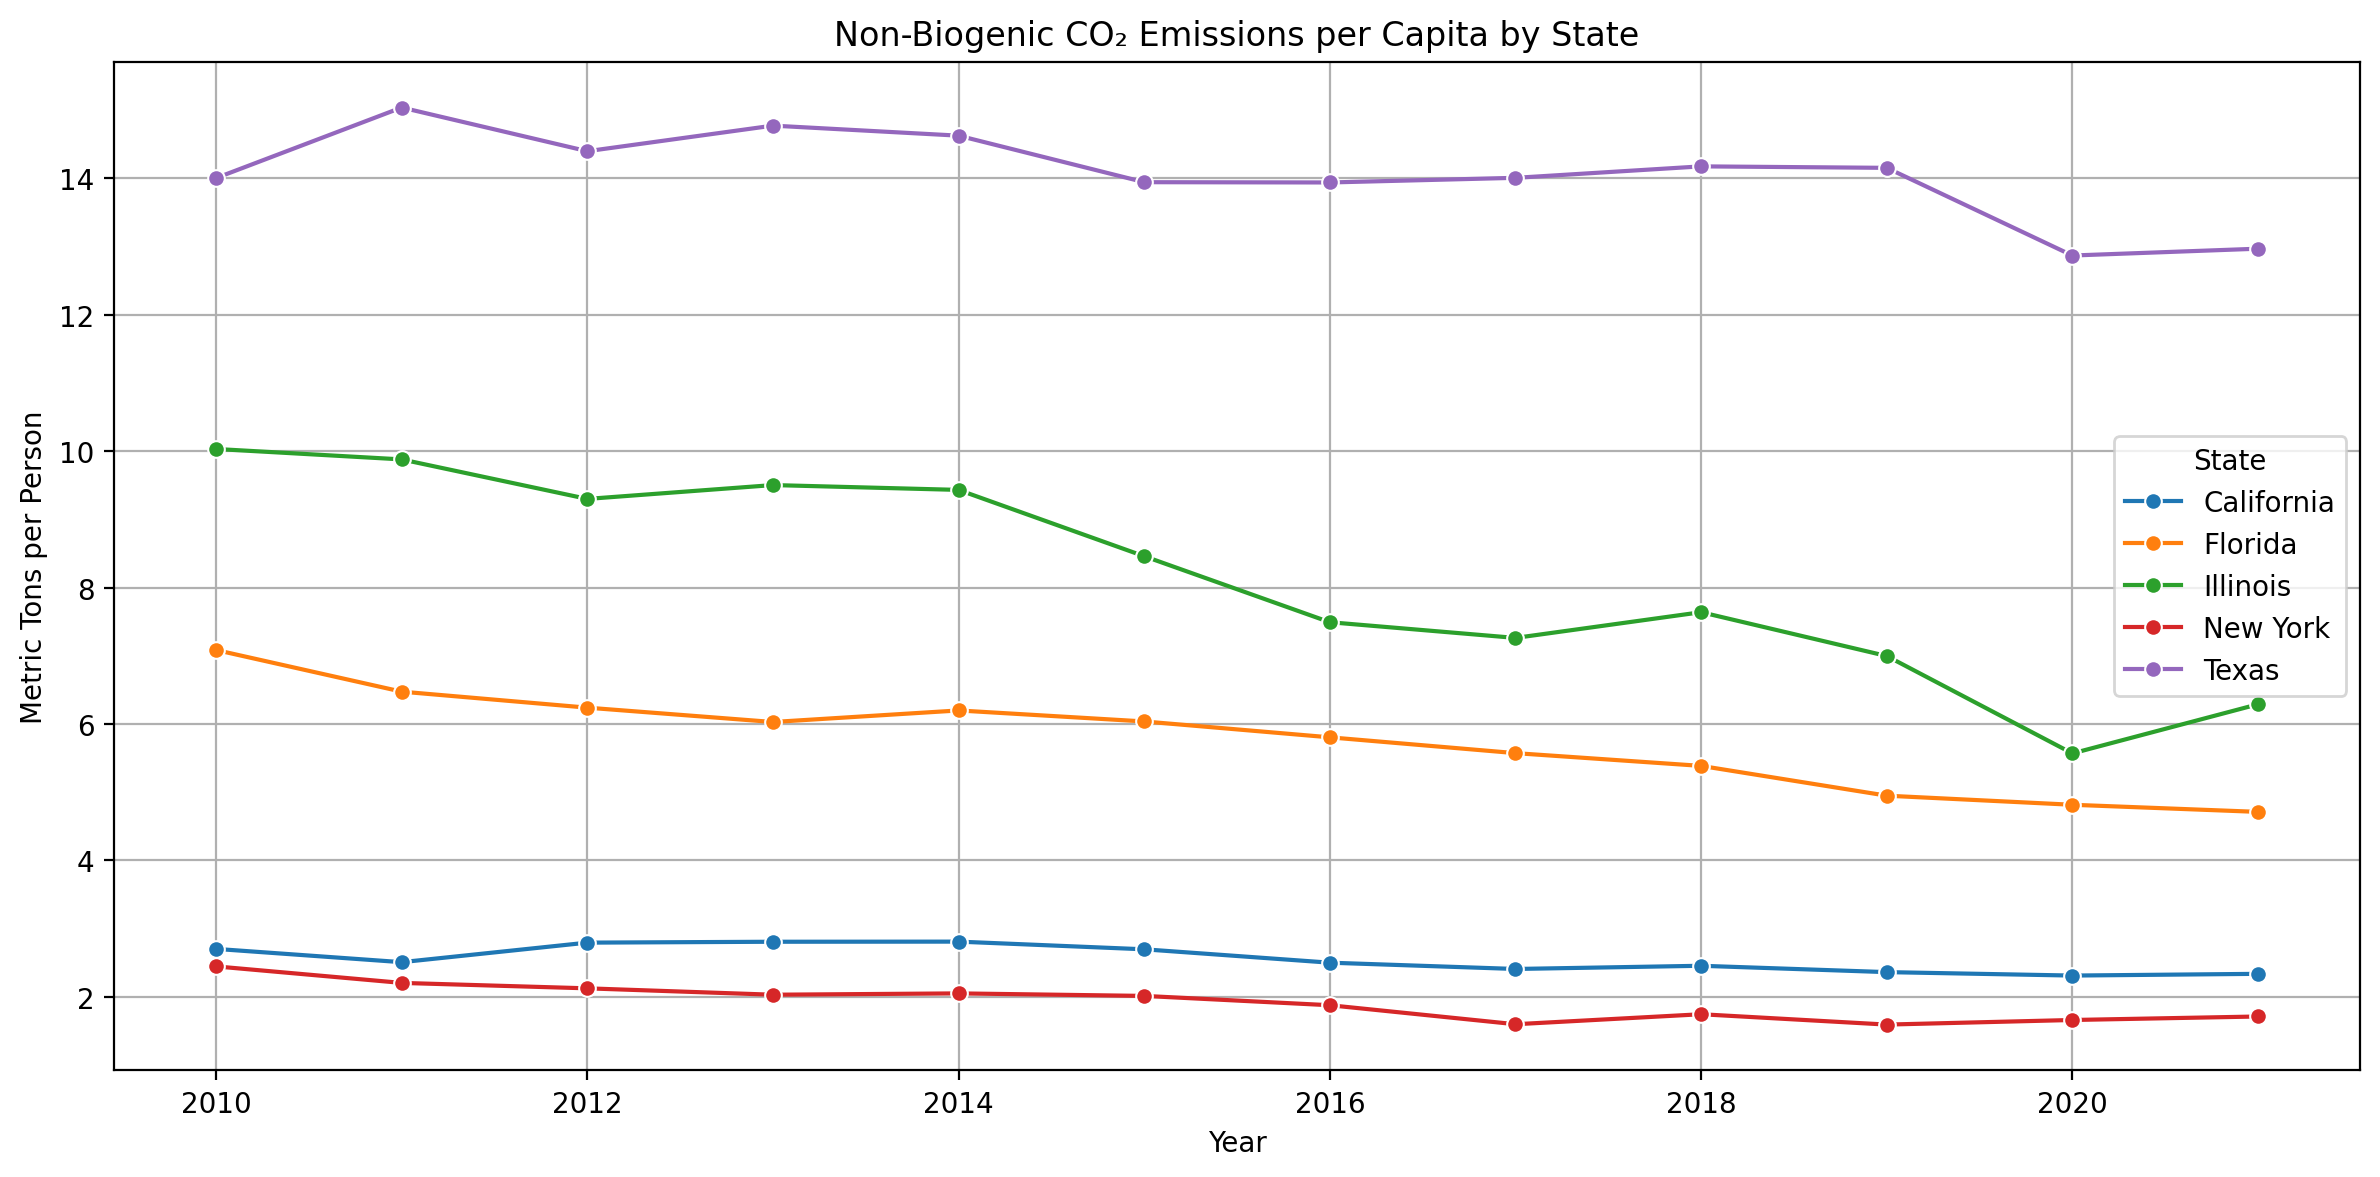

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a few states to compare
selected_states = ['California', 'Texas', 'Florida', 'New York', 'Illinois']

# Filter the dataframe
plot_df = df_wide[df_wide['Name'].isin(selected_states)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Year', y='CO2_NonBio_per_capita', hue='Name', marker='o')

plt.title("Non-Biogenic CO₂ Emissions per Capita by State")
plt.ylabel("Metric Tons per Person")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.legend(title="State")
plt.show()


### 📊 Interpretation: Non-Biogenic CO₂ per Capita Trends

This line chart shows the **non-biogenic CO₂ emissions per person** across five major U.S. states from 2010 to 2021.

- **Texas** has consistently the **highest per capita emissions**, likely due to energy production and industry.
- **New York** and **California** show the **lowest levels**, reflecting strong environmental regulations and energy efficiency efforts.
- **Illinois** and **Florida** are in the middle, but show a general **downward trend** over time.

> ✅ This kind of visualization helps policymakers and researchers evaluate the effectiveness of emission reduction strategies.


### 🔍 What to Look For

- Which states have the **highest per-person emissions**?
- Are emissions **increasing or decreasing** over time?
- Are any states moving in **opposite directions**?

> 🧠 You can easily change the `selected_states` list to explore different regions or create regional comparisons (e.g., West Coast vs Midwest).


## 📊 Step 8.2: Compare Different Gases per Capita (Single State View)

We’ve looked at how one metric changes over time across states.

Now let’s flip the question:
> **How do multiple emission types compare within a single state?**

We’ll plot several **per capita metrics** for one state (e.g., California), using Seaborn.


## ✅ Code Cell: Line Plot of Multiple Metrics (One State)

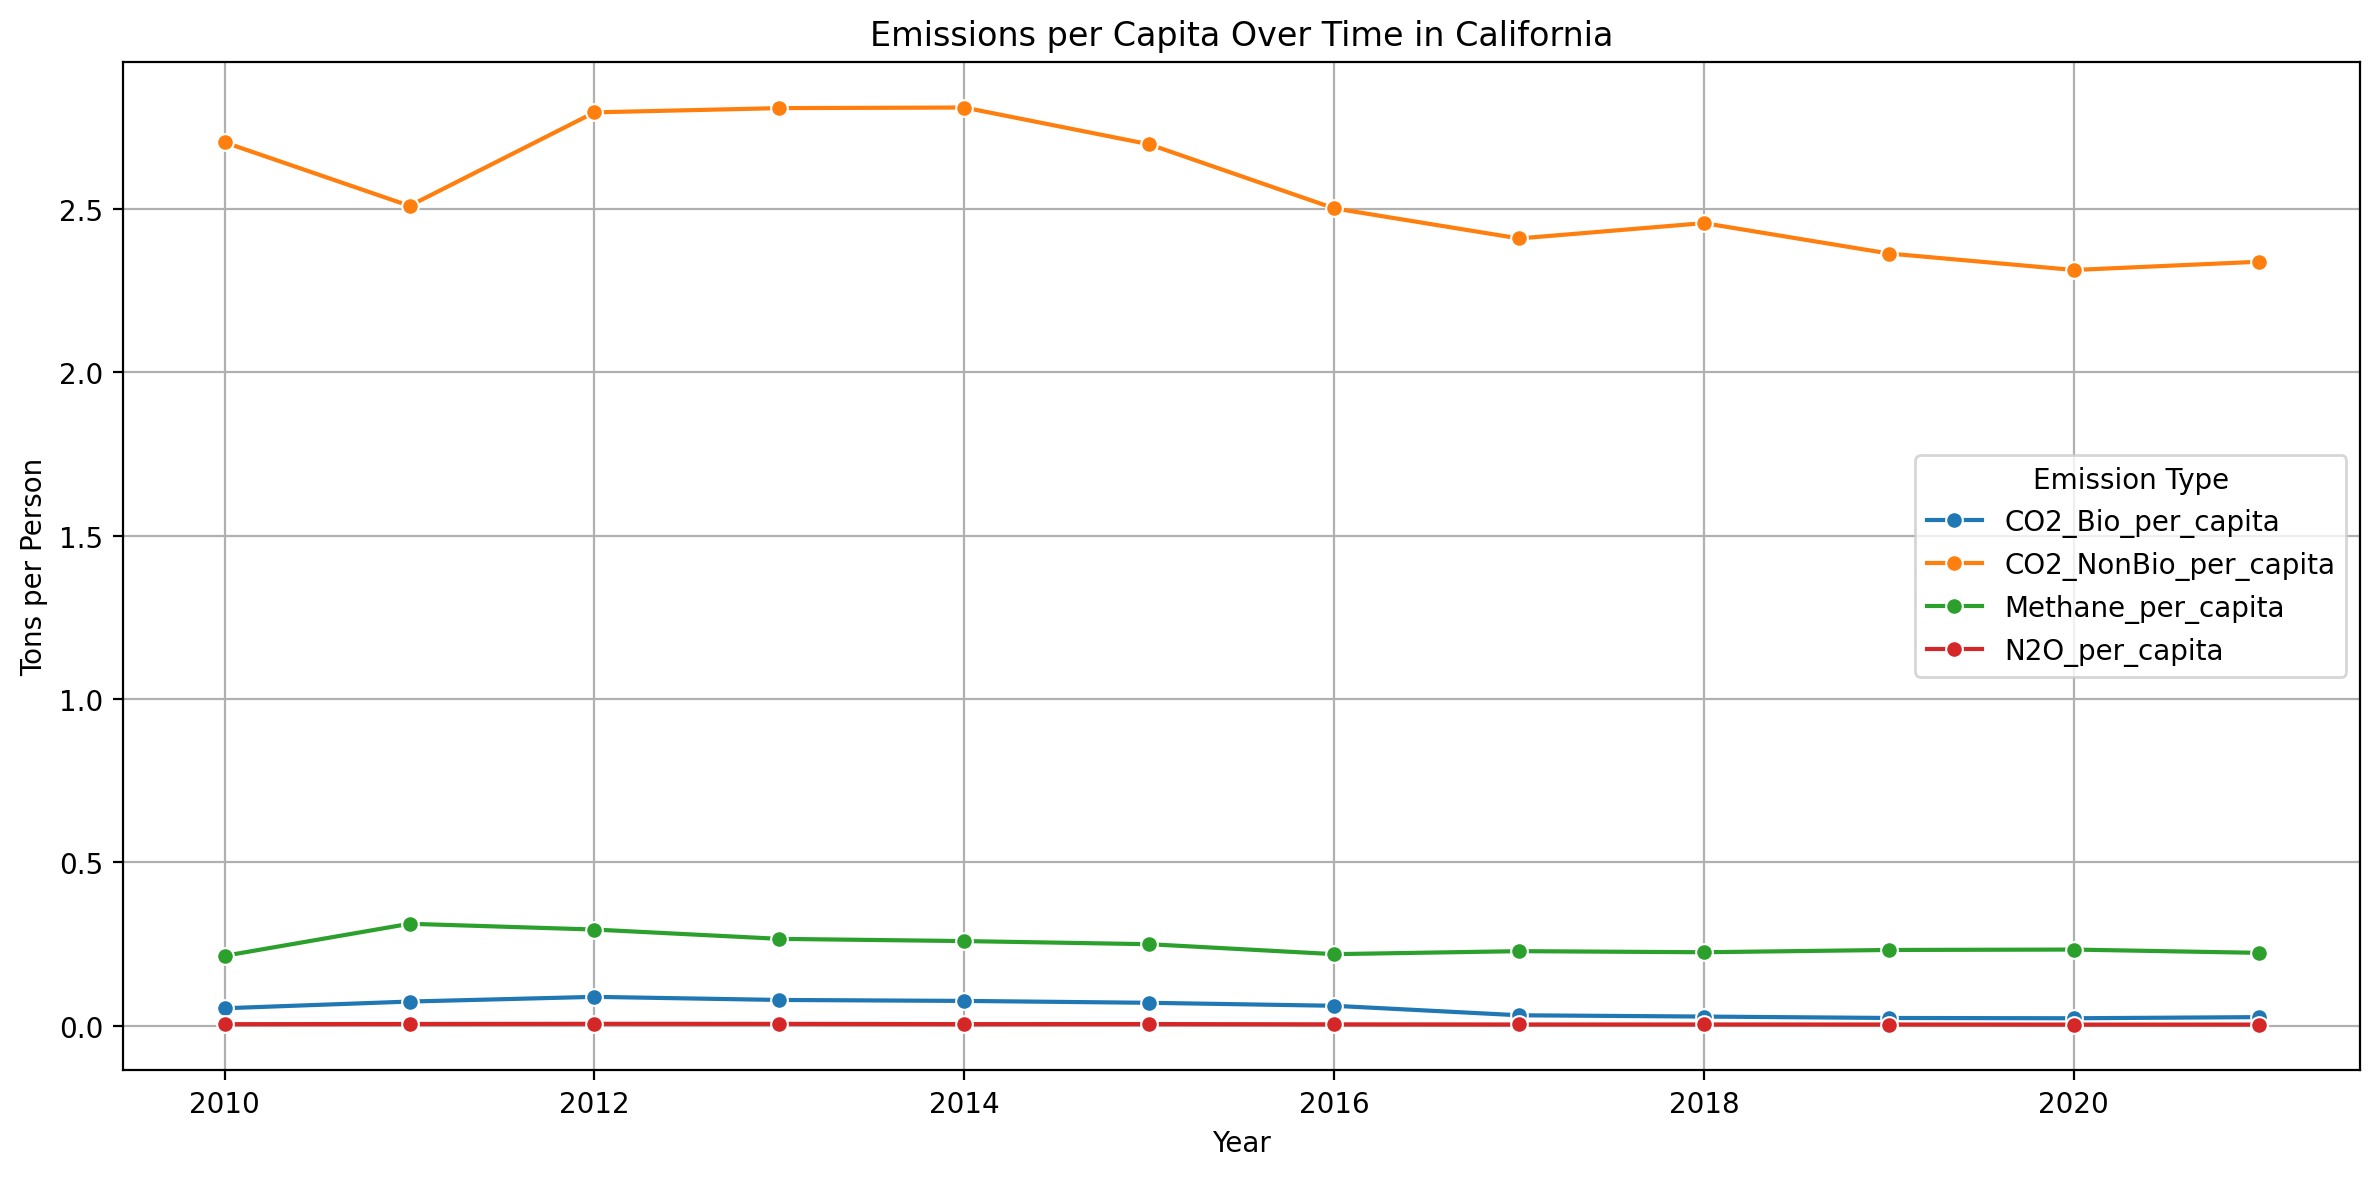

In [66]:
# Choose a state to explore
selected_state = 'California' ## you can change the state here

# Filter data
state_df = df_wide[df_wide['Name'] == selected_state]

# Melt the DataFrame to long format
melted = state_df.melt(
    id_vars=['Year'],
    value_vars=[
        'CO2_Bio_per_capita',
        'CO2_NonBio_per_capita',
        'Methane_per_capita',
        'N2O_per_capita'
    ],
    var_name='Metric',
    value_name='PerCapitaValue'
)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted, x='Year', y='PerCapitaValue', hue='Metric', marker='o')

plt.title(f"Emissions per Capita Over Time in {selected_state}")
plt.ylabel("Tons per Person")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Emission Type")
plt.show()


### 📊 Interpretation of Multi-Metric Plot

- **Non-Biogenic CO₂** is clearly the dominant emission per capita in California.
- **Methane (CH₄)** emissions are noticeably lower but still significant.
- **Biogenic CO₂** and **Nitrous Oxide (N₂O)** are minimal by comparison.
- The overall per-person emissions profile is **declining or stabilizing** over time, especially for CO₂.

This kind of comparison helps reveal **which types of emissions drive the state's overall footprint** — and how targeted policies might reduce specific gases.


### 🔍 What This Tells Us

- You can now **directly compare different gases** for a single state.
- You’ll often see **CO₂ (non-biogenic)** dominating.
- **Methane and N₂O** vary but tend to be lower.

This is useful for understanding the **emissions profile** of each state.

> 🔁 Want to explore a different state? Just change `selected_state`.


---

## 🧭 What’s Next: Interactive Plotly Dashboard

We’ve now visualized emissions by:
- 📈 Single metric across states (Step 8.1)
- 📊 Multiple metrics for one state (Step 8.2)

> 💡 **Why Interactivity Matters in Google Data Commons**
>
> Google Data Commons isn't just a data source — it's a **discovery platform** built on a **knowledge graph**.  
> With thousands of variables, locations, and relationships, **interactive exploration** becomes essential.  
> Static plots are great for predefined questions — but **dynamic dashboards help uncover new patterns**, compare across dimensions, and truly explore the knowledge graph.

So what if you want to:
- Compare multiple **states AND metrics** interactively?
- Select from dropdowns instead of hardcoding values?
- Quickly explore trends without writing new code?

🎛️ Let’s build an **interactive Plotly explorer** where you can:
- Select states and metrics on the fly
- Zoom into time periods
- Hover to see exact values

---


# Section 3: Interactive **Data Commons** Plots with Plotly

---

## 🎛️ Step 9: Interactive Emissions Explorer with Plotly

Now that we’ve seen how to plot emissions data using Seaborn, let's make the experience dynamic and interactive.

Using **Plotly**, we’ll build an explorer tool that allows you to:
- ✅ Select one or more states
- ✅ Choose emission variables to compare
- ✅ Zoom into specific years
- ✅ Hover to see precise values

> ⚠️ **Important Note:**
> Plotly interactive charts require running this notebook in **Google Colab**, **Jupyter**, or **JupyterLab**.
> If you are viewing this in GitHub or a static environment, the interactive plot **will not render**.
>
> To help with this, we’ll include **static preview images** of the charts below each Plotly cell.

---

### 🔄 How This Ties Back to Knowledge Discovery

Data Commons is designed to be **exploratory** — it contains thousands of interconnected indicators.  
Instead of hardcoding what to analyze, this dashboard lets **you drive your own investigation**.

Think of it as:
> 🧭 A knowledge discovery tool for surfacing insights hidden in the graph.

Let’s build it!

---


## 📦 Code: Step 9.1 – Interactive Plotly Chart (Single State + Variable)

## 📊 Step 9.1: Explore Emissions Trends by State & Variable

Use the interactive dropdowns below to select:
- A **state**
- An **emission variable** (e.g. CO₂, methane)

You'll get an interactive Plotly plot (⚠️ requires **Colab**, **Jupyter**, or a compatible environment).  
If viewing this notebook on GitHub or another static site, refer to the **static snapshot below** each plot for reference.


## 🎛️ Interactive Emissions Explorer (Plotly Version)

In this section, we build an interactive dashboard for exploring U.S. emissions data across states and metrics using **Plotly**.

Plotly is a powerful Python visualization library that supports dynamic, browser-based charts. It allows us to create **fully interactive experiences** with:
- Dropdown menus for selecting states and emission types
- Hover tooltips and zoom functionality
- A timeline slider for narrowing the view to recent years

We define a reusable class, `EmissionsExplorer`, that:
- Loads and stores the emissions data
- Constructs a Plotly chart with all state-metric combinations
- Adds dropdown controls for switching views
- Exports static snapshots if needed

> 💡 For more on how Plotly works, you can explore the [Plotly Python documentation](https://plotly.com/python/).

📌 If your environment does not support interactive Plotly output (e.g., static notebook viewers like GitHub), you can skip to the **Matplotlib** version below that recreates the same visualizations as static PNG charts.


## ✅ Code Cell: Interactive Plot where you can choose state and metric displayed - helper functions (Just run the code below!)

The code below will define helper function we discussed to plot the interactive graphs. You don't need details on how the class works - in the cells below we explain how to reuse this class with other data you may create in Data Commons.

In [105]:
import plotly.graph_objects as go
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import os


class EmissionsExplorer:
    def __init__(self, df, metrics, default_state=None, default_metric=None):
        self.df = df
        self.states = df['Name'].unique()
        self.metrics = metrics
        self.default_state = default_state or self.states[0]
        self.default_metric = default_metric or self.metrics[0]
        self.min_year = 2000
        self.max_year = df['Year'].max()
        print("✅ Setup complete! You can now generate interactive or static emissions plots below.")

    def create_interactive_plot(self):
        fig = go.Figure()

        # Add traces for all state-metric combinations
        for metric in self.metrics:
            for state in self.states:
                data = self.df[self.df['Name'] == state]
                fig.add_trace(go.Scatter(
                    x=data['Year'],
                    y=data[metric],
                    mode='lines+markers',
                    name=f'{state} - {metric}',
                    visible=False
                ))

        # Make only the default trace visible
        for i, trace in enumerate(fig.data):
            if trace.name == f'{self.default_state} - {self.default_metric}':
                fig.data[i].visible = True

        # Dropdown for states
        state_dropdown = {
            "buttons": [
                {
                    "label": state,
                    "method": "update",
                    "args": [
                        {"visible": [
                            trace.name == f"{state} - {self.default_metric}" for trace in fig.data
                        ]},
                        {"title": f"{state} - {self.default_metric}"}
                    ]
                } for state in self.states
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.01,
            "xanchor": "left",
            "y": 1.2,
            "yanchor": "top"
        }

        # Dropdown for metrics
        metric_dropdown = {
            "buttons": [
                {
                    "label": metric,
                    "method": "update",
                    "args": [
                        {"visible": [
                            trace.name == f"{self.default_state} - {metric}" for trace in fig.data
                        ]},
                        {"title": f"{self.default_state} - {metric}"}
                    ]
                } for metric in self.metrics
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.25,
            "xanchor": "left",
            "y": 1.2,
            "yanchor": "top"
        }

        # Layout (adjusted top margin to prevent button/title overlap)
        fig.update_layout(
            title=f"{self.default_state} - {self.default_metric}",
            xaxis_title="Year",
            yaxis_title="Emissions",
            updatemenus=[state_dropdown, metric_dropdown],
            margin=dict(t=120),  # 🔧 Adjusted here
            xaxis=dict(
                rangeslider=dict(visible=True),
                rangeselector=dict(
                    buttons=[
                        dict(count=5, label="Last 5Y", step="year", stepmode="backward"),
                        dict(count=10, label="Last 10Y", step="year", stepmode="backward"),
                        dict(step="all", label="All")
                    ]
                ),
                range=[self.min_year, self.max_year]
            )
        )

        return fig

    def generate_static_plots(self, state_metric_pairs):
        file_paths = []
        for i, (state, metric) in enumerate(state_metric_pairs):
            data = self.df[self.df['Name'] == state]
            fig = go.Figure()
            fig.add_trace(go.Scatter(
                x=data['Year'],
                y=data[metric],
                mode='lines+markers',
                name=f'{state} - {metric}'
            ))
            fig.update_layout(
                title=f"{state} - {metric}",
                xaxis_title="Year",
                yaxis_title="Emissions",
                xaxis=dict(range=[self.min_year, self.max_year])
            )

            path = os.path.join(static_output_dir, f"{state}_{metric}.png")
            pio.write_image(fig, path, format="png", scale=2)
            file_paths.append(path)

        return file_paths



# Display will be handled in the next step
"✅ Setup complete! You can now generate interactive or static emissions plots below."



'✅ Setup complete! You can now generate interactive or static emissions plots below.'

> **You are not suppose to see any output in this cell yet, this is a helper
> class for visualization that will be used below**

## Using the plotly visualizer class with Data Commons Data
Now that we have defined functions to plot out interactive graph, let's plot it




## ⚙️ Using the `EmissionsExplorer` Class for Interactive Plotting

The `EmissionsExplorer` class is a reusable tool that allows you to build an interactive emissions dashboard using **Plotly**.

You don't need to modify the class itself — instead, you can use it by simply creating an instance and passing in your own data and a list of metrics.

---

### 🧩 Required Inputs

When you create an explorer object like this:

```python
explorer = EmissionsExplorer(df=df_wide, metrics=[
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic',
    'CO2_Bio_per_capita',
    'CO2_NonBio_per_capita',
    'Methane_per_capita',
    'N2O_per_capita'
])
```

You are telling the explorer:

* 📊 What DataFrame to use (df)

* 📌 What metrics you want to make selectable in the dropdowns


The class will automatically:

* Detect all state names (df['Name'])

* Find the year range

* Set the first state and metric as defaults (you can override that too)


## ⚙️ Using the `EmissionsExplorer` Class with Your Own Data

The `EmissionsExplorer` class is reusable and works with any emissions-style dataset, as long as the format is consistent.

---

### 🔁 Reusing with Your Own Data

To use this class with a different dataset:

1. ✅ Make sure your DataFrame has the following columns:
   - `"Name"` — the state or region name
   - `"Year"` — numeric year values
   - At least one emissions metric column (e.g., `"CO2_Total"`, `"Methane"`, etc.)

2. ✅ Then instantiate and use the class like this:

```python
explorer = EmissionsExplorer(
    df=my_emissions_data,
    metrics=['CO2_Total', 'Methane']
)
fig = explorer.create_interactive_plot()
fig.show()
```


You’ll get a fully interactive plot with dropdowns and timeline navigation — no extra setup required.




## 🔍 What’s Next?
Once the interactive figure is rendered:

* 📍 You can switch between states and metrics via dropdowns

* 🕓 Use the slider to zoom in on recent years

* 📈 Hover to see exact emission values per year

> ⚠️ If your current environment does not support Plotly interactivity (e.g., > GitHub, PDF),
> scroll down to the next section to view static plots recreated using Matplotlib.



## 📦 Code Cell:  Interactive Plots - run this cell to view the visualization we created

In [106]:
import warnings
from IPython.display import display, Markdown

# Suppress warnings (especially Plotly deprecation warnings)
warnings.filterwarnings("ignore")

# Create explorer instance
explorer = EmissionsExplorer(df=df_wide, metrics=[
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic',
    'CO2_Bio_per_capita',
    'CO2_NonBio_per_capita',
    'Methane_per_capita',
    'N2O_per_capita'
])

# Create and show interactive Plotly figure
fig = explorer.create_interactive_plot()
fig.update_layout(
    margin=dict(t=120),  # or t=150 if needed
)

fig.show()

# Fallback message
display(Markdown("""
> ✅ **Here is the interactive emissions explorer powered by Plotly.**
>
> If you **cannot see the plot above** (e.g., you're on GitHub or a static notebook viewer),
> please scroll down to the next code cells which **recreate the same plots using Matplotlib**
> for static export or offline use.
> or opt out to preview this notebook in **Google Colab** or **jupyter notebook**.
"""))


✅ Setup complete! You can now generate interactive or static emissions plots below.



> ✅ **Here is the interactive emissions explorer powered by Plotly.**  
> 
> If you **cannot see the plot above** (e.g., you're on GitHub or a static notebook viewer),  
> please scroll down to the next code cells which **recreate the same plots using Matplotlib**  
> for static export or offline use.
> or opt out to preview this notebook in **Google Colab** or **jupyter notebook**.


# What does this interactive plot tell us ?

✅ Here is the interactive emissions explorer powered by Plotly.

This plot lets you **dynamically explore** emissions trends across states and metrics using dropdowns.

From a Data Commons perspective, this is powerful because:
- We're pulling **real-time time series data** from the knowledge graph
- The interactive layout enables **exploratory knowledge discovery**: what variables vary across states? how do emissions correlate with population?

⚠️ Note: If you're viewing this notebook statically (e.g. on GitHub), you may not see the interactive chart above. In that case, refer to the static Matplotlib plots below.


# Static Matplotlib Plots for Emissions Data

## 📦 Code Cell:  Static Grid Generator Cell (Customize your view here)

If you couldn't or do not want to use Plotly you can create dynamic exploration with traditional Python visualization tools like matplotlib - they will be in static format rather then interactive html.

### 🖼️ Static Snapshots for GitHub or PDF Export

If Plotly isn't supported (e.g. GitHub renderers or PDF export), we use:

- `matplotlib` to recreate the same plots as PNGs
- Side-by-side comparisons by **fixing either a state or a metric**
- Example: Viewing emissions trends across **5 metrics** for **California**

> You can change the `fixed_state` or `fixed_metric` variables in the code to produce your own grid of static charts.

---



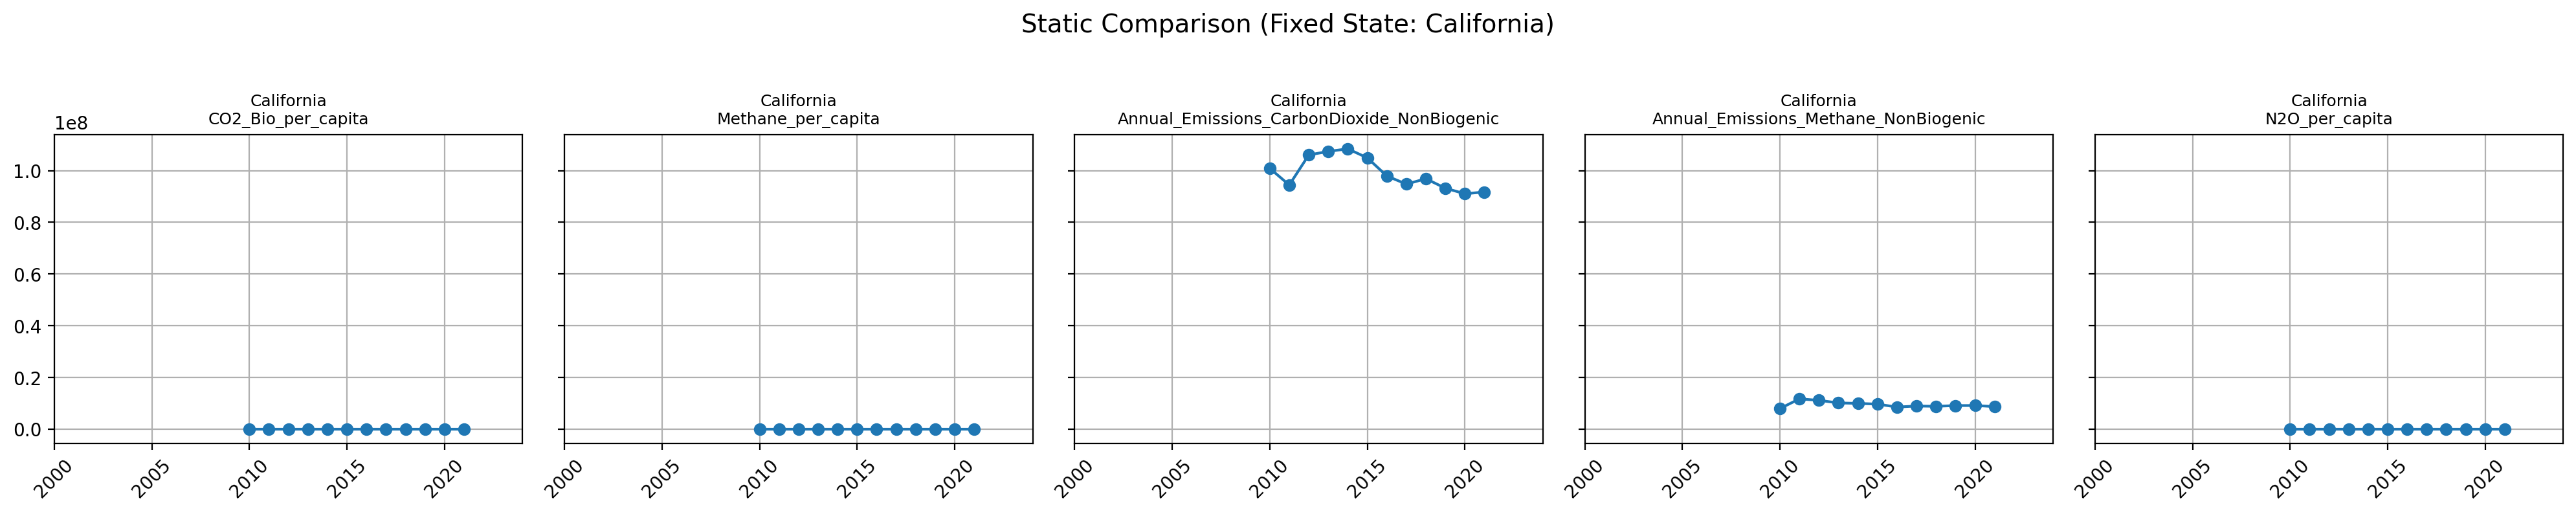

In [90]:
import matplotlib.pyplot as plt

# --------------------------
# ⚙️ SETTINGS (Customize here)
# --------------------------

# ✅ FIXED STATE across multiple metrics
fixed_state = "California"  # 👈 change to fix a different state
metrics_to_plot = [
    "CO2_Bio_per_capita",
    "Methane_per_capita",
    "Annual_Emissions_CarbonDioxide_NonBiogenic",
    "Annual_Emissions_Methane_NonBiogenic",
    "N2O_per_capita"
]

# ✅ OR, FIXED METRIC across multiple states
# fixed_metric = "Methane_per_capita"
# states_to_plot = ["California", "Texas", "New York", "Florida", "Illinois"]

# --------------------------
# 📊 STATIC PLOTS SIDE BY SIDE
# --------------------------

fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4), sharey=True)

for i, metric in enumerate(metrics_to_plot):
    data = df_wide[df_wide["Name"] == fixed_state]
    axs[i].plot(data["Year"], data[metric], marker='o', color='tab:blue')
    axs[i].set_title(f"{fixed_state}\n{metric}", fontsize=9)
    axs[i].set_xlim(2000, data["Year"].max())
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].grid(True)

fig.suptitle(f"Static Comparison (Fixed State: {fixed_state})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


🖼️ These static line plots replicate the Plotly dashboard views.

They are provided to ensure visibility for GitHub viewers or others who cannot render Plotly widgets.  
Each subplot shows emissions over time for a **fixed state (California)** across different emissions types.

While not interactive, they give a **quick comparative glance** at different pollutant behaviors over time.




# 🧮 Section 4: Optional Metrics Enabled by Data Commons

In this section, we explore how the **richness and flexibility** of the Data Commons knowledge graph allows us to go beyond emissions and population data.

Because Data Commons links thousands of variables across environmental, demographic, and infrastructure domains, we can easily enrich our dataset with **climate and behavioral context**, such as:

- 🌡️ **Heating and Cooling Degree Days** — derived from annual temperature data
- 🚗 **Vehicle Availability per Household** — transportation patterns that may affect emissions

These optional additions are made possible by the unified schema and variable coverage of the Data Commons API.

Let’s start by calculating **degree days**, a common metric used in climate and energy modeling.


## 🌡️ Step 10.1: What Are Degree Days?

**Degree days** are a simple but powerful way to estimate how much heating or cooling energy might be needed in a given year, based on temperature patterns.

- **Cooling Degree Days (CDD)**: Sum of the degrees that the average daily temperature was above 65°F (18.3°C). Used to estimate air conditioning demand.
- **Heating Degree Days (HDD)**: Sum of the degrees that the average daily temperature was below 65°F. Used to estimate heating demand.

We'll calculate these using **mean daily temperature** data for each state and year, accessed via the Data Commons variable:



```
Daily_AverageTemperature
```


> 🔍 This variable is sourced from datasets like NOAA or NASA and standardized into the Data Commons schema.  
> This allows us to effortlessly combine it with **emissions**, **population**, and location metadata — something that would require significant cleaning and joining in most other workflows.


## ✅ Step 10.2 — Code Cell: Retrieve Mean Temperature

In [110]:
# Function to compute monthly HDD and CDD
def degree_day_df(dcid):
    """Pulls monthly mean temperature for a state and calculates CDD and HDD"""
    mean_temps = dc.get_stat_series(dcid, "Mean_Temperature")
    base_temperature = 18.3  # 65°F

    years = []
    month_names = []
    month_numbers = []
    hdd_values = []
    cdd_values = []

    for month_year, mean_temp in mean_temps.items():
        year = int(month_year[:4])
        month_number = int(month_year[5:])
        month_name = pd.to_datetime(month_year, format='%Y-%m').strftime('%B')

        # Calculate CDD and HDD
        cdd = max(mean_temp - base_temperature, 0)
        hdd = max(base_temperature - mean_temp, 0)

        years.append(year)
        month_names.append(month_name)
        month_numbers.append(month_number)
        hdd_values.append(hdd)
        cdd_values.append(cdd)

    return pd.DataFrame({
        'State': dcid,
        'Year': years,
        'Month': month_numbers,
        'Month_Name': month_names,
        'CDD': cdd_values,
        'HDD': hdd_values
    }).sort_values(by=['Year', 'Month'])


##  ✅ Step 10.3 — Loop Through All States

In [111]:
# Build degree day dataset for all states
HCC_CDD_df = pd.DataFrame()

for s in states_list:
    try:
        temp_df = degree_day_df(s)
        HCC_CDD_df = pd.concat([HCC_CDD_df, temp_df])
    except Exception as e:
        print(f"Failed for {s}: {e}")


## ✅ Step 10.4 — Add State Names

In [112]:
# Add readable state names
HCC_CDD_df['Name'] = HCC_CDD_df['State'].map(state_names)


> ✅ Thanks to the standardized schema of Data Commons, we’re able to retrieve monthly mean temperature data (`Mean_Temperature`) across all states using the same API call.
>
> From this, we calculate **cooling and heating degree days** using a base threshold of 18.3°C (65°F), a common benchmark in energy modeling.
>
> These values can be used to understand how temperature-related energy demand varies by location and year — and could even be correlated with emissions.


## ✅ Step 10.5 — Aggregate Monthly Degree Days to Annual

In [113]:
# Aggregate monthly values into annual totals per state
HCC_CDD_annual = (
    HCC_CDD_df
    .groupby(['State', 'Year'])
    .agg({'CDD': 'sum', 'HDD': 'sum'})
    .reset_index()
)

# Add readable state names for reference (if not already in df_wide)
HCC_CDD_annual['Name'] = HCC_CDD_annual['State'].map(state_names)


## ✅ Step 10.6 — Merge with df_wide

In [114]:
# Merge degree day data into the main emissions dataset
df_wide = df_wide.merge(
    HCC_CDD_annual[['State', 'Year', 'CDD', 'HDD']],
    on=['State', 'Year'],
    how='left'
)

# Preview result
df_wide[['Name', 'Year', 'CDD', 'HDD']].dropna().head()


,Name,Year,CDD,HDD
79,Alabama,1979,28.4954,48.97336
80,Alabama,1980,38.2460,49.18166
81,Alabama,1981,33.6163,47.12325
82,Alabama,1982,31.3326,37.78606
83,Alabama,1983,30.4305,50.68054


> 📦 We've now added `CDD` and `HDD` values — total Cooling and Heating Degree Days per year per state — into our main dataset.
>
> This allows you to:
> - Visualize the relationship between climate and emissions
> - Explore how emissions vary in states with high heating or cooling needs


## ✅ Step 10.7 — Visualization: Emissions vs. Cooling Demand

## 🔍 Exploring Climate-Emissions Interactions Across States

Thanks to Data Commons, we’ve easily combined variables from multiple domains:
- **Emissions** (EPA, energy databases)
- **Population** (Census)
- **Temperature/Climate** (NOAA/NASA)

This unified structure allows us to explore questions like:

> 🧠 Are the states with the highest **Cooling Degree Days** also the states with the highest **per capita CO₂ emissions**?

Let’s visualize this for a specific year using a scatter plot.


-----
## 📊 Plot: CO₂ per Capita vs Cooling Degree Days (2021)

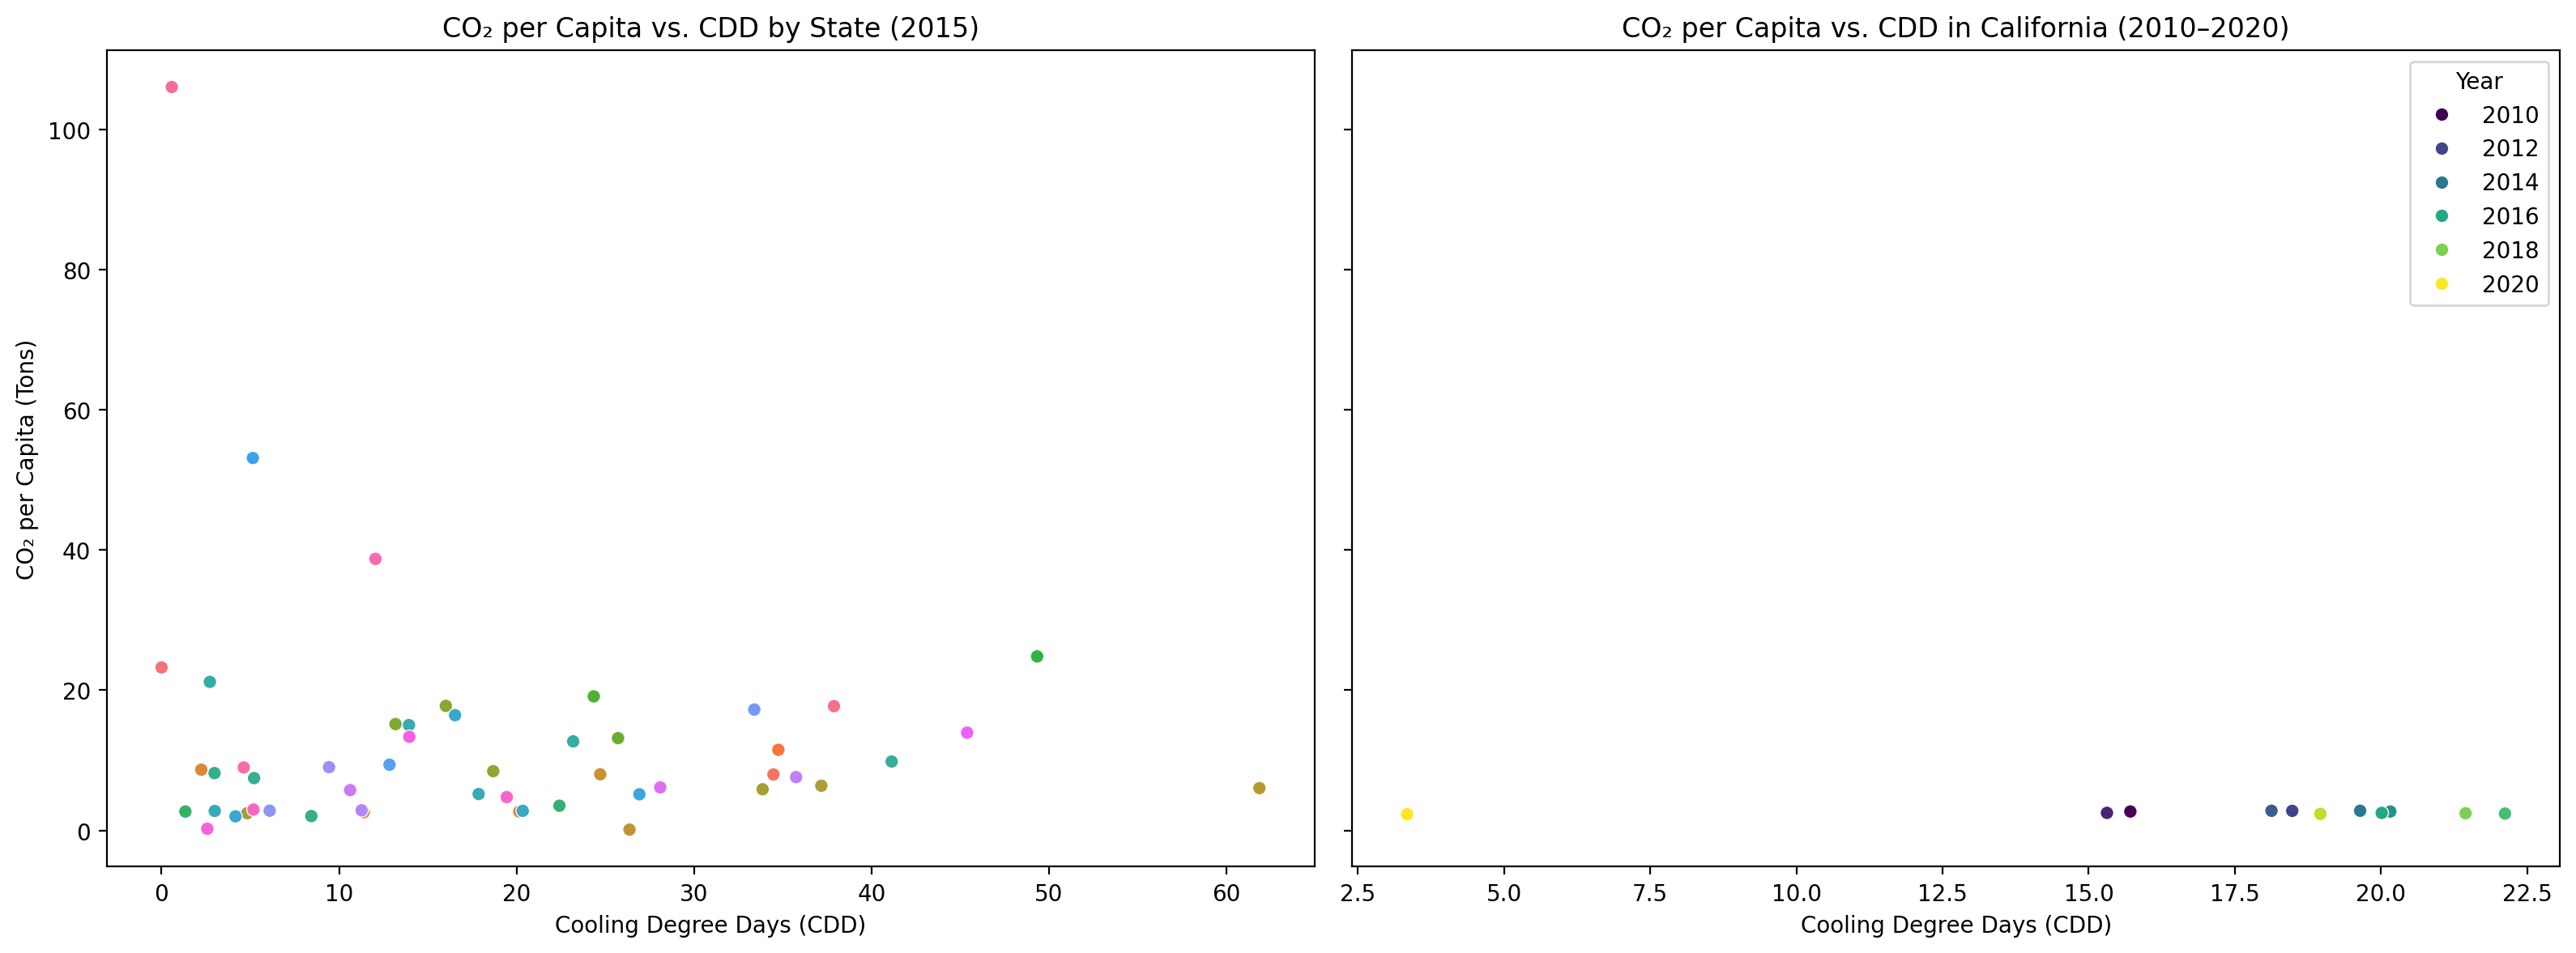

In [124]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data - you should already have df_wide with proper columns
# Filter by years with complete data (2010 to 2020)
valid_years = list(range(2010, 2021))
df_filtered = df_wide[df_wide['Year'].isin(valid_years)].dropna(subset=['CDD', 'CO2_NonBio_per_capita'])

# Select one state for time trend (e.g., California)
df_state = df_filtered[df_filtered['Name'] == 'California']

# Select one year for cross-sectional view (e.g., 2015)
df_year = df_filtered[df_filtered['Year'] == 2015]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: Across States in 2015
sns.scatterplot(data=df_year, x='CDD', y='CO2_NonBio_per_capita', hue='Name', ax=axes[0], legend=False)
axes[0].set_title("CO₂ per Capita vs. CDD by State (2015)")
axes[0].set_xlabel("Cooling Degree Days (CDD)")
axes[0].set_ylabel("CO₂ per Capita (Tons)")

# Plot 2: Across Years for California
sns.scatterplot(data=df_state, x='CDD', y='CO2_NonBio_per_capita', hue='Year', palette='viridis', ax=axes[1])
axes[1].set_title("CO₂ per Capita vs. CDD in California (2010–2020)")
axes[1].set_xlabel("Cooling Degree Days (CDD)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


> 📊 **Summary: Emissions vs. Degree Days**

In this step, we explored how **Data Commons** enables quick enrichment of emissions data with **climate metrics** like Cooling Degree Days (CDD).

By combining per capita CO₂ emissions with temperature-derived variables, we created a **multi-dimensional dataset** and visualized patterns across both **space** (states) and **time** (years).

🔗 This level of integration—normally requiring complex joins and cleaning—is made effortless by Data Commons' shared schema and standardized DCIDs.

Next, we’ll apply the same pattern to explore **vehicle ownership metrics**.


## 🚗 Optional Metrics: Vehicle Ownership Patterns

As a second enrichment example, we’ll pull detailed **vehicle availability metrics** from Data Commons. These variables describe how many households in each state have access to 0, 1, 2, 3, or 4+ vehicles, broken down by household size.

🔍 This enables nuanced exploration of questions like:
- Do states with fewer vehicles per household have lower emissions?
- How does vehicle availability correlate with per capita emissions?

📡 Thanks to Data Commons, these household-level statistics are:
- Already **standardized** across time and location,
- Instantly joinable with emissions, population, and temperature data using **DCIDs**.

We’ll retrieve, clean, and prepare this dataset just like we did for emissions and degree days.


## ✅ Step 11 — Fetch Vehicle Ownership Data



In [125]:
# Define the vehicle-related variables
vehicles_variable_list = [
    'Count_Household_With0AvailableVehicles',
    'Count_Household_With1AvailableVehicles',
    'Count_Household_With2AvailableVehicles',
    'Count_Household_With3AvailableVehicles',
    'Count_Household_With4OrMoreAvailableVehicles',
    'Count_Household_With4OrMorePerson_With0AvailableVehicles',
    'Count_Household_With4OrMorePerson_With1AvailableVehicles',
    'Count_Household_With4OrMorePerson_With2AvailableVehicles',
    'Count_Household_With4OrMorePerson_With3AvailableVehicles',
    'Count_Household_With4OrMorePerson_With4OrMoreAvailableVehicles',
    'Count_Household_With1Person_With2AvailableVehicles',
    'Count_Household_With1Person_With3AvailableVehicles',
    'Count_Household_With1Person_With4OrMoreAvailableVehicles',
    'Count_Household_With2Person_With0AvailableVehicles',
    'Count_Household_With2Person_With1AvailableVehicles',
    'Count_Household_With2Person_With2AvailableVehicles',
    'Count_Household_With2Person_With3AvailableVehicles',
    'Count_Household_With2Person_With4OrMoreAvailableVehicles',
    'Count_Household_With3Person_With0AvailableVehicles',
    'Count_Household_With3Person_With1AvailableVehicles',
    'Count_Household_With3Person_With2AvailableVehicles',
    'Count_Household_With3Person_With3AvailableVehicles',
    'Count_Household_With3Person_With4OrMoreAvailableVehicles'
]

# Fetch time series data from Data Commons
vehicles_data = []

for state in states_list:
    for var in vehicles_variable_list:
        try:
            stat_series = datacommons.get_stat_series(state, var)
            for year, value in stat_series.items():
                vehicles_data.append({
                    'State': state,
                    'Year': int(year),
                    'Variable': var,
                    'Value': value
                })
        except Exception as e:
            print(f"⚠️ Error fetching data for {state} and {var}: {e}")

# Convert to DataFrame
df_vehicles = pd.DataFrame(vehicles_data)
df_vehicles['Name'] = df_vehicles['State'].map(state_names)
df_vehicles.head()


,State,Year,Variable,Value,Name
0,geoId/01,2022,Count_Household_With0AvailableVehicles,107641,Alabama
1,geoId/01,2013,Count_Household_With0AvailableVehicles,118518,Alabama
2,geoId/01,2019,Count_Household_With0AvailableVehicles,113960,Alabama
3,geoId/01,2023,Count_Household_With0AvailableVehicles,106155,Alabama
4,geoId/01,2012,Count_Household_With0AvailableVehicles,118707,Alabama


### 🚗 Retrieving Vehicle Ownership Metrics from Data Commons

In this step, we used the Data Commons API to fetch **time series data** on household vehicle availability across all U.S. states.

Each variable represents the number of households by:
- **Number of vehicles available** (0 to 4+), and
- **Household size** (1–4+ persons)

We looped through 23 standardized variables and used `get_stat_series()` to retrieve state-level data over time.

> ✅ Because all these variables share a common schema and spatial reference (DCID-based), they can be queried consistently and integrated directly into our emissions dataset — no manual matching or cleaning required.
----

## ✅ Step 12: Integrate Vehicle Metrics into Main Dataset

In [126]:
# Pivot the vehicle data to get one column per vehicle variable
df_vehicles_wide = df_vehicles.pivot_table(
    index=['State', 'Year'],
    columns='Variable',
    values='Value'
).reset_index()

# Merge into df_wide using State and Year as keys
df_wide = pd.merge(df_wide, df_vehicles_wide, on=['State', 'Year'], how='left')

# Preview result
df_wide[df_wide['Year'] == 2020].head()


,State,Year,Annual_Emissions_CarbonDioxide_Biogenic,Annual_Emissions_CarbonDioxide_NonBiogenic,Annual_Emissions_Methane_NonBiogenic,Annual_Emissions_NitrousOxide_NonBiogenic,Count_Person,CO2_Bio_per_capita,CO2_NonBio_per_capita,Methane_per_capita,...,Count_Household_With3Person_With1AvailableVehicles,Count_Household_With3Person_With2AvailableVehicles,Count_Household_With3Person_With3AvailableVehicles,Count_Household_With3Person_With4OrMoreAvailableVehicles,Count_Household_With4OrMoreAvailableVehicles,Count_Household_With4OrMorePerson_With0AvailableVehicles,Count_Household_With4OrMorePerson_With1AvailableVehicles,Count_Household_With4OrMorePerson_With2AvailableVehicles,Count_Household_With4OrMorePerson_With3AvailableVehicles,Count_Household_With4OrMorePerson_With4OrMoreAvailableVehicles
120,geoId/01,2020,10927739.0,62793376.9,8635219.725,322703.902,4921532.0,2.220394,12.758909,1.754580,...,55497.0,108968.0,83742.0,37548.0,164935.0,6870.0,45686.0,146009.0,91723.0,74651.0
195,geoId/02,2020,1922.5,17070189.4,825448.500,19325.896,731158.0,0.002629,23.346786,1.128960,...,8407.0,14753.0,9039.0,4557.0,20239.0,5506.0,8948.0,25880.0,13626.0,9562.0
320,geoId/04,2020,356346.2,39664432.3,1306908.000,561727.318,7421401.0,0.048016,5.344602,0.176100,...,72436.0,154339.0,99179.0,29689.0,179836.0,15921.0,86046.0,254428.0,149351.0,106538.0
445,geoId/05,2020,4709384.7,29612211.0,2085514.000,153478.046,3030522.0,1.553985,9.771324,0.688170,...,38027.0,71146.0,49945.0,16611.0,83012.0,6165.0,35833.0,100629.0,56698.0,41361.0
570,geoId/06,2020,883807.3,91064955.9,9162385.250,120064.796,39368078.0,0.022450,2.313167,0.232736,...,416707.0,891673.0,603588.0,201256.0,1252077.0,93152.0,443654.0,1453789.0,960179.0,863809.0


Thanks to Data Commons' use of **consistent DCIDs** for geographic entities and variables, we were able to:

- Fetch this new dataset in the same way as emissions and climate data
- Seamlessly merge it into our `df_wide` dataset by matching on `State` and `Year`

> This integration showcases how **Data Commons enables rich, multi-dimensional datasets** to be assembled without manually joining messy external sources.

We'll now use these new variables to further explore trends in mobility, household infrastructure, and their potential relationship to emissions.


## Now we can explore the encriched dataset to explore relationships between the variables, for example, let's plot :

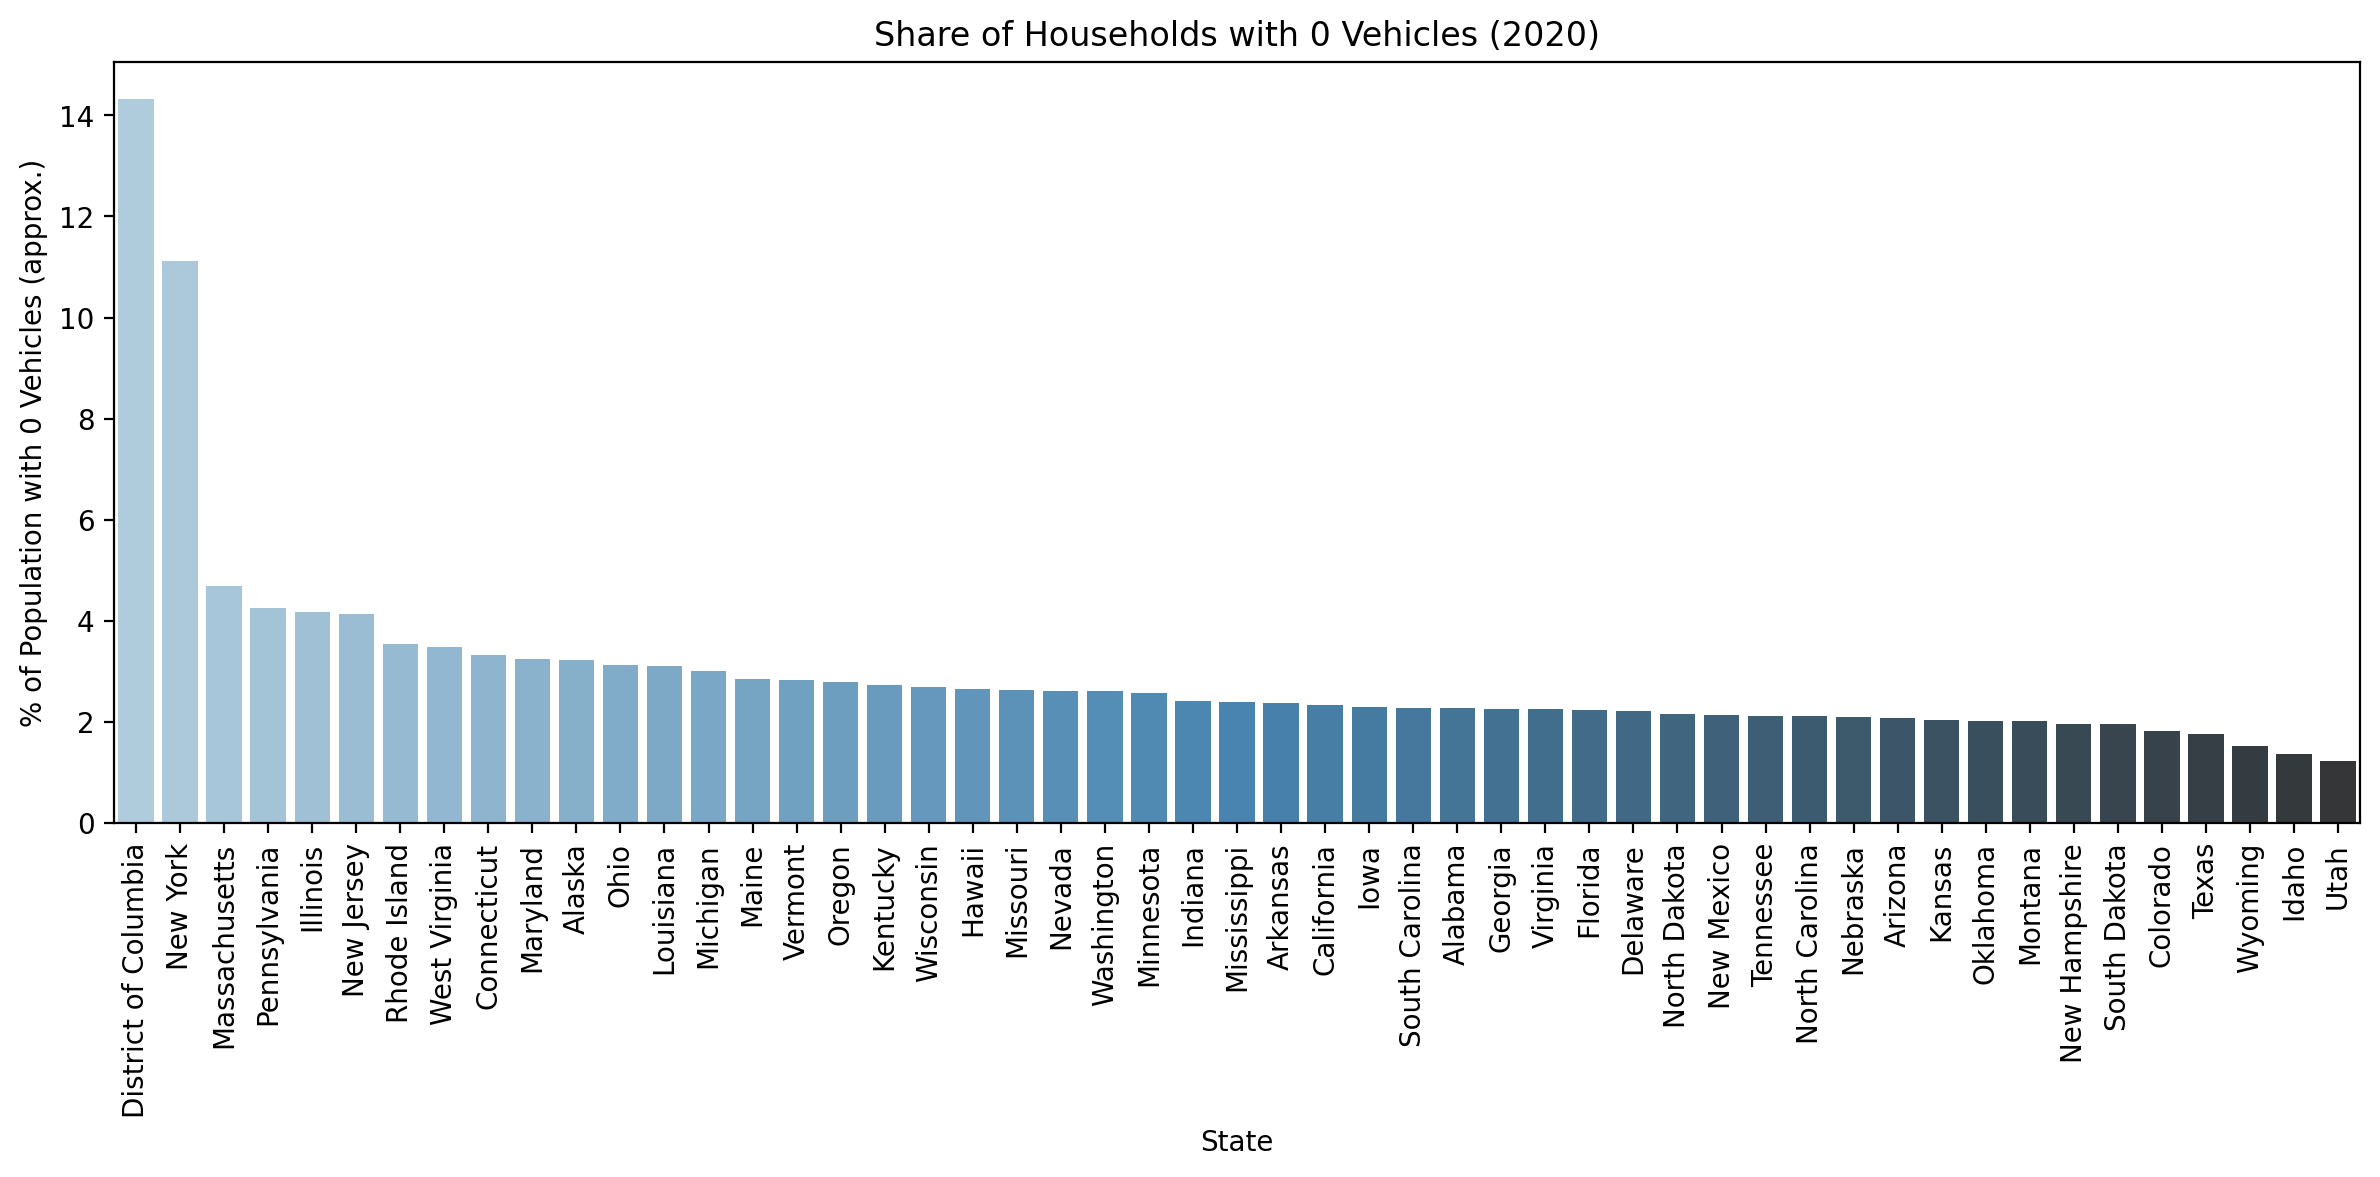

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select variable and year
var_zero_vehicles = 'Count_Household_With0AvailableVehicles'
year_to_plot = 2020

# Filter and calculate share of households with 0 vehicles
df_plot = df_wide[df_wide['Year'] == year_to_plot].copy()
df_plot['Pct_Zero_Vehicles'] = (
    df_plot[var_zero_vehicles] / df_plot['Count_Person'] * 100
)

# Drop missing
df_plot = df_plot.dropna(subset=['Pct_Zero_Vehicles'])

# Barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot.sort_values('Pct_Zero_Vehicles', ascending=False),
            x='Name', y='Pct_Zero_Vehicles', palette='Blues_d')

plt.title(f"Share of Households with 0 Vehicles (2020)")
plt.ylabel("% of Population with 0 Vehicles (approx.)")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


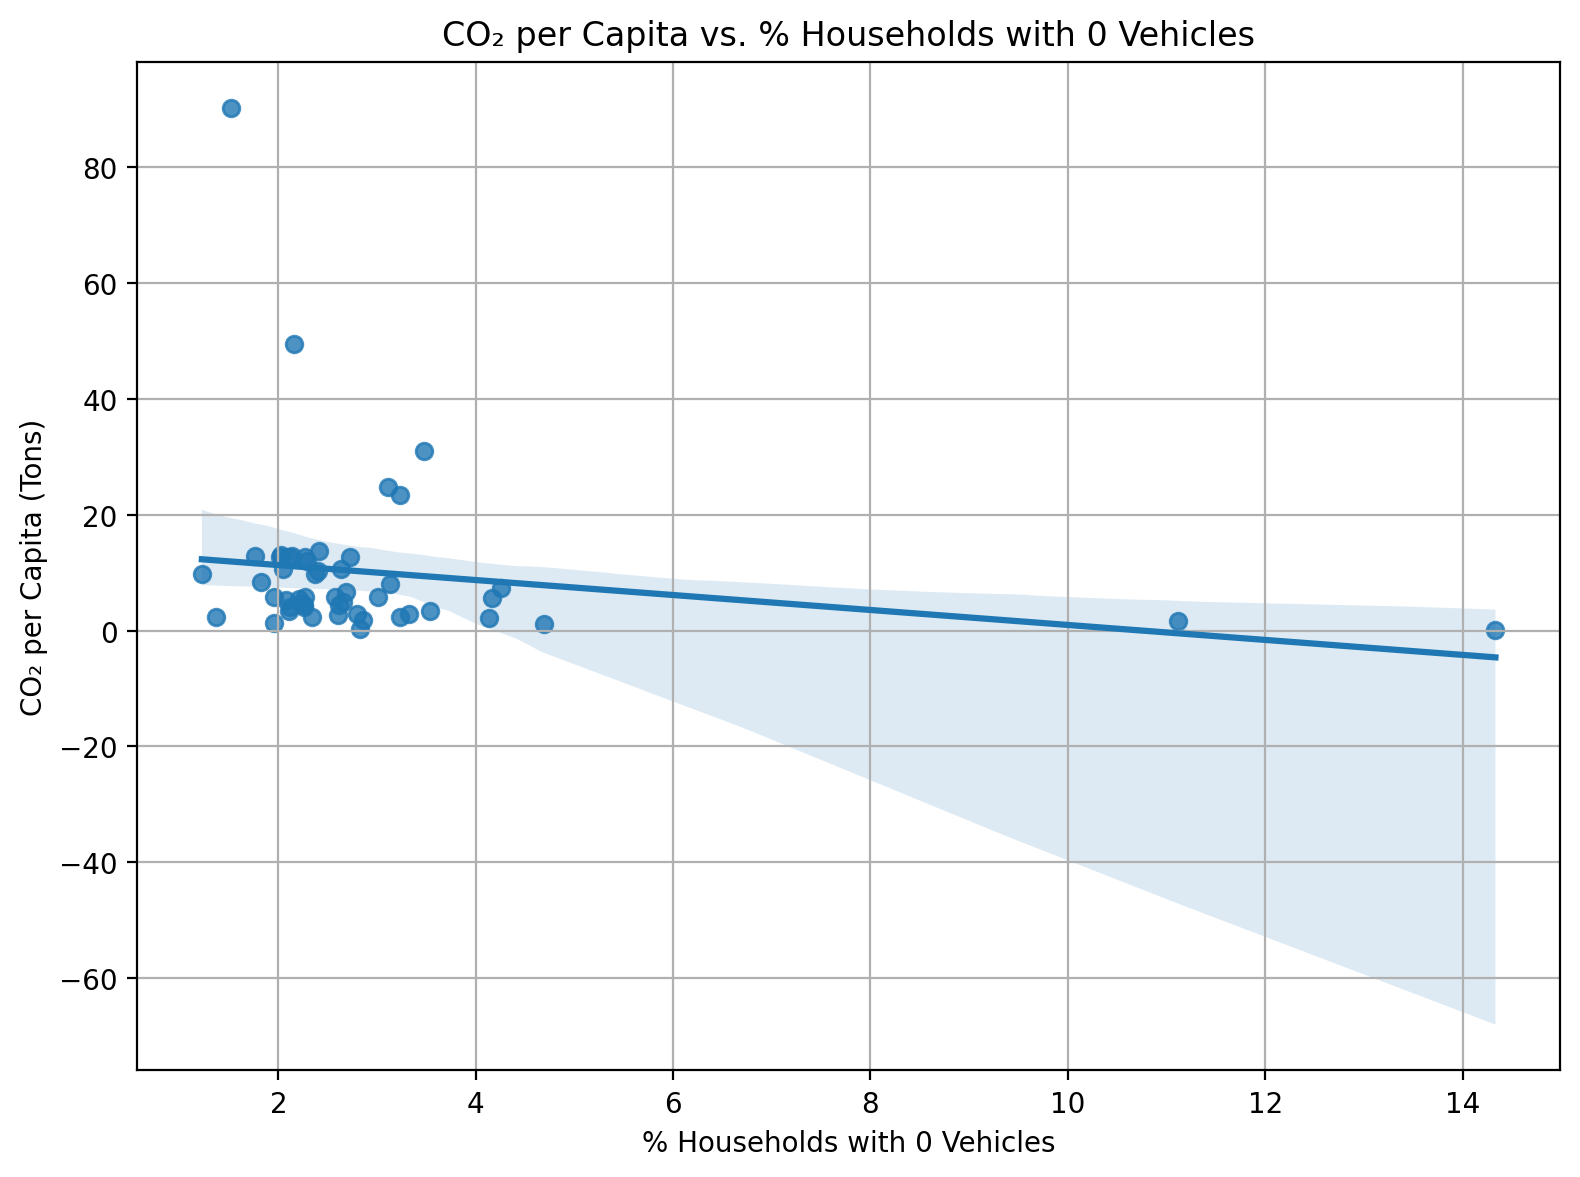

In [128]:
# Drop NaNs for both columns
df_scatter = df_plot.dropna(subset=['CO2_NonBio_per_capita', 'Pct_Zero_Vehicles'])

# Scatter plot
plt.figure(figsize=(8, 6))
sns.regplot(data=df_scatter, x='Pct_Zero_Vehicles', y='CO2_NonBio_per_capita')

plt.title("CO₂ per Capita vs. % Households with 0 Vehicles")
plt.xlabel("% Households with 0 Vehicles")
plt.ylabel("CO₂ per Capita (Tons)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Combining data we retrieved for nuanced insights

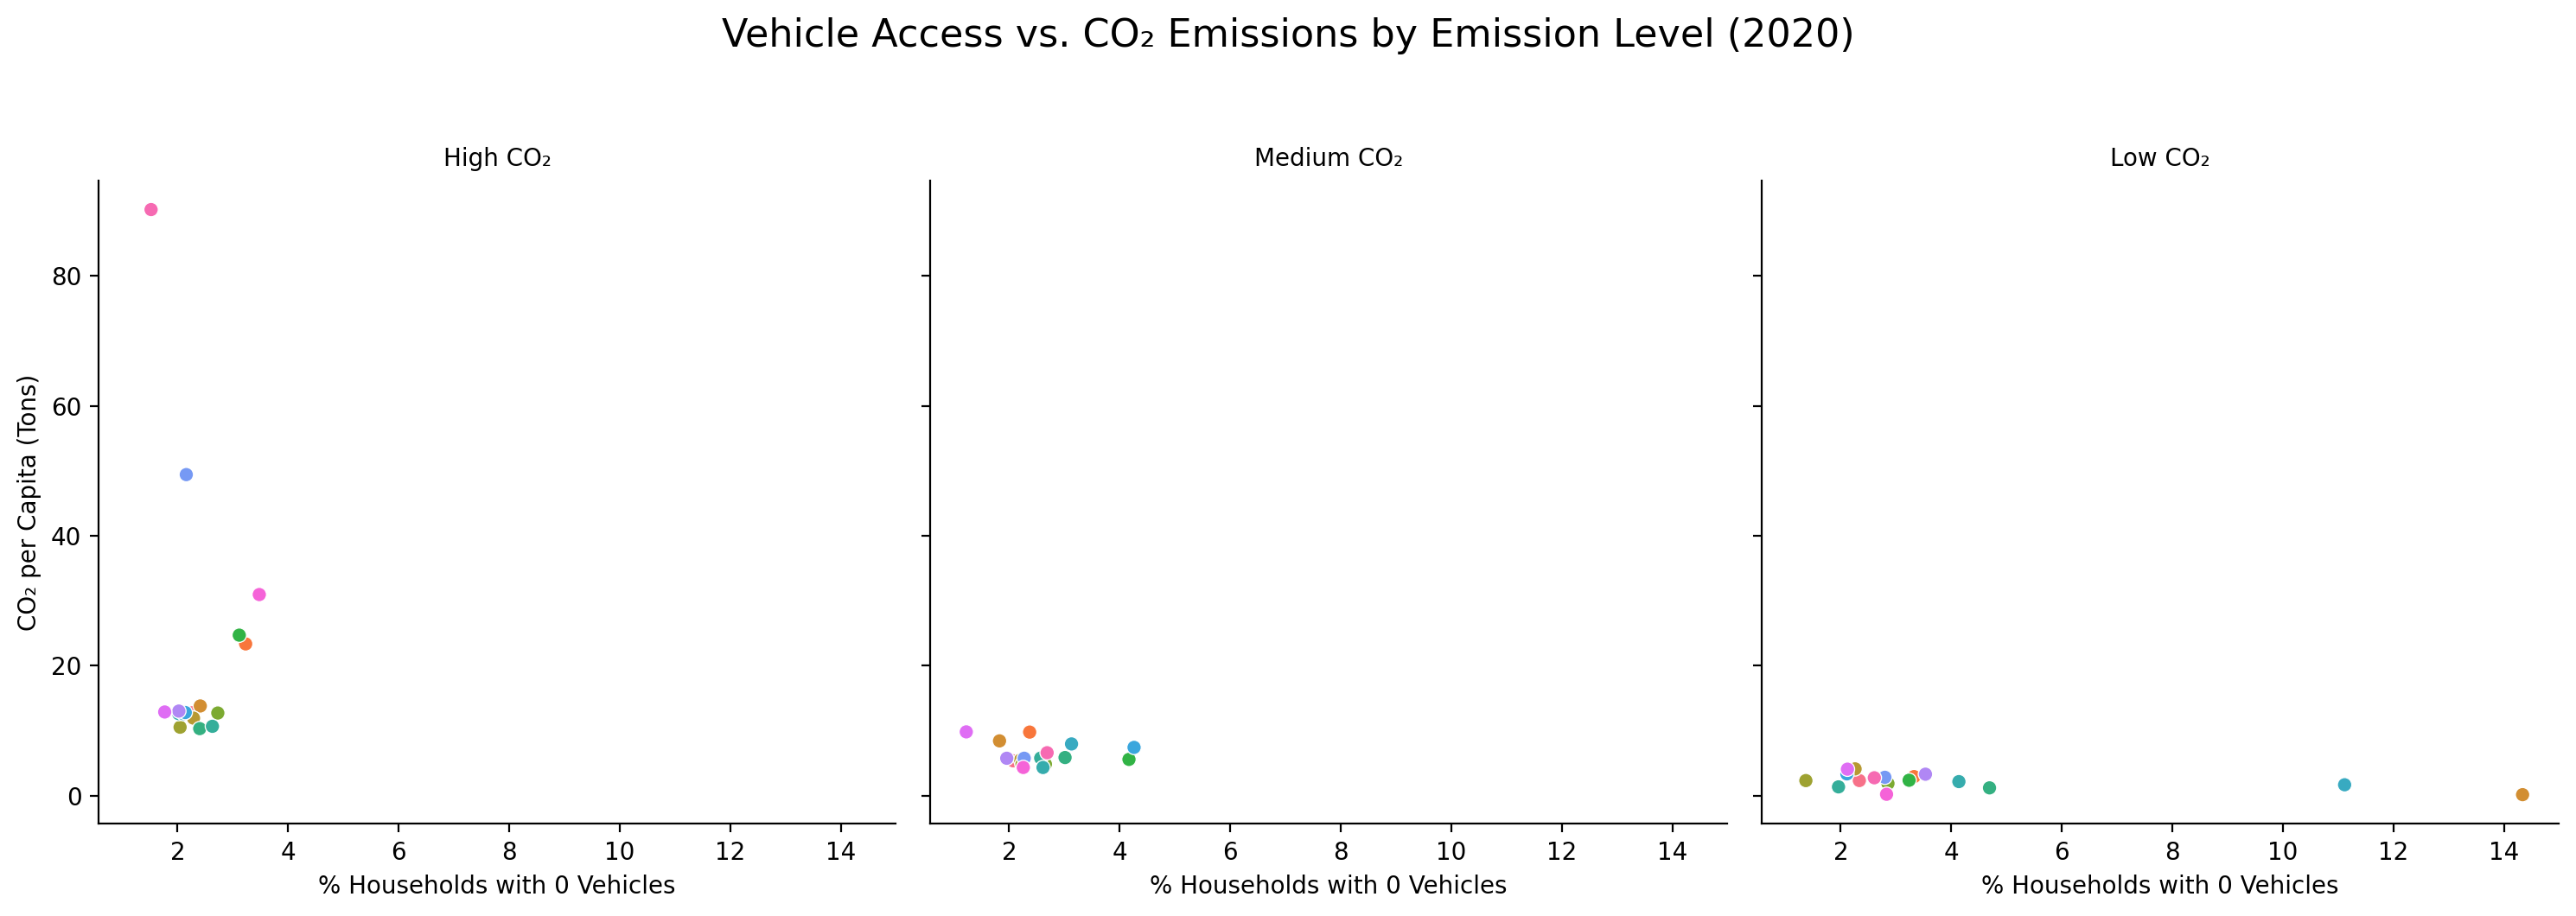

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use latest available full data year
latest_year = 2020

# Filter data
df_plot = df_wide[df_wide['Year'] == latest_year].copy()

# Calculate share of zero-vehicle households (approximation)
df_plot['Pct_Zero_Vehicles'] = (
    df_plot['Count_Household_With0AvailableVehicles'] / df_plot['Count_Person']
) * 100

# Drop NaNs
df_plot = df_plot.dropna(subset=['Pct_Zero_Vehicles', 'CO2_NonBio_per_capita'])

# Classify states by CO₂ per capita: low, medium, high
q1 = df_plot['CO2_NonBio_per_capita'].quantile(0.33)
q2 = df_plot['CO2_NonBio_per_capita'].quantile(0.66)

def classify_emission(val):
    if val <= q1:
        return 'Low CO₂'
    elif val <= q2:
        return 'Medium CO₂'
    else:
        return 'High CO₂'

df_plot['CO2_Class'] = df_plot['CO2_NonBio_per_capita'].apply(classify_emission)

# Set up FacetGrid for scatterplots
g = sns.FacetGrid(
    df_plot,
    col='CO2_Class',
    height=5,
    aspect=1,
    sharey=True,
    sharex=True
)

# Plot vehicle availability vs population
g.map_dataframe(
    sns.scatterplot,
    x='Pct_Zero_Vehicles',
    y='CO2_NonBio_per_capita',
    hue='Name'
)

g.set_axis_labels("% Households with 0 Vehicles", "CO₂ per Capita (Tons)")
# g.add_legend()
g.set_titles("{col_name}")

plt.suptitle("Vehicle Access vs. CO₂ Emissions by Emission Level (2020)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


## 🚗 Vehicle Access & Emissions – Powered by Data Commons

In this section, we explored household vehicle availability using data from the `get_stat_series()` API. Thanks to the **unified schema** in Data Commons, we easily merged vehicle data with emissions, population, and geographic metadata.

### 🔍 Insights from the Plots

- **Bar Chart**: States like D.C. and New York have the highest % of households with 0 vehicles.
- **Scatterplot**: States with fewer vehicles per household tend to have lower CO₂ per capita.
- **Faceted View**: When partitioned by emission levels (High, Medium, Low), the link between vehicle access and emissions varies—revealing deeper contextual patterns.

📌 These insights are enabled by **cross-domain data integration**—a core strength of the Data Commons platform.

Next up: **Graph-based exploration and interconnectivity in GDC.**


## ✅ Summary: What We Learned